In [1]:
import jax
jax.config.update('jax_enable_x64', True)  # Use float64
jax.config.update("jax_default_matmul_precision", "highest")

import inference
import models
import visualizations
import utils

import numpy as np
import jax.numpy as jnp
import numpyro
from numpyro import optim
import matplotlib.pyplot as plt


# Load

In [3]:
from scipy.io import loadmat

#import data
SATED_DECONV = np.load('../Data/predictions_fullTrace_sated.npy', allow_pickle=True)
ANG_STIM_DATA = loadmat('../Data/metadata_deconv/stimAngle_sated.mat', simplify_cells=True)
SF_STIM_DATA  = loadmat('../Data/metadata_deconv/stimSpatFreq_sated.mat', simplify_cells=True)
SATED_ANGLE = ANG_STIM_DATA['order_of_stim_arossAnimals']
SATED_SF    = SF_STIM_DATA['stimSpatFreq_arossAnimals']

HUNGRY_DECONV = np.load('../Data/predictions_fullTrace_hungry.npy', allow_pickle=True)
ANG_STIM_DATA_HUNGRY = loadmat('../Data/metadata_deconv/stimAngle_hungry.mat', simplify_cells=True)
SF_STIM_DATA_HUNGRY  = loadmat('../Data/metadata_deconv/stimSpatFreq_hungry.mat', simplify_cells=True)
HUNGRY_ANGLE = ANG_STIM_DATA_HUNGRY['order_of_stim_arossAnimals']
HUNGRY_SF    = SF_STIM_DATA_HUNGRY['stimSpatFreq_arossAnimals']

def resort_preprocessing(datum,angle_arr,sf_arr,animal):
    data = np.copy(datum[animal,:])
    neurons = data[0].shape[0]
    reshape_data = np.full((60,neurons,data[0].shape[1]), np.nan)
    for i in range(60):
        reshape_data[i,:,:] = data[i]

    reshape_data = reshape_data.reshape(60,neurons,12,120)
    reshape_data = np.transpose(reshape_data,(1,2,0,3))
    #Remove first two neurons
    reshape_data = reshape_data[2:,:,:,:]

    #Remove None trials
    max_trial = np.argmax(np.isnan(reshape_data[0,1,:,0]))
    reshape_data = reshape_data[:,:,:max_trial,:]

    # Remove beginning and last bit # HMMMM should I do this?
    # reshape_data[:,0,:,:32] = np.nan
    # reshape_data[:,-1,:,88:] = np.nan
    # print(np.any(np.isnan(reshape_data)))
    # print(reshape_data.shape)
    
    # Reorder angles
    angles = np.copy(angle_arr[animal])
    for itrials in range(angles.shape[1]):
        order = angles[:,itrials]-1
        reshape_data[:,:,itrials,:] = reshape_data[:,order,itrials,:]

    # Reorder SFs
    reshaped_data = []
    sfs = np.copy(sf_arr[animal])
    for experiment in range(1,6):
        mask = sfs == experiment
        reshaped_data.append(reshape_data[:,:,mask,:])

    max_trials = max([exp.shape[2] for exp in reshaped_data])
    # Pad the data for experiments with (10, 12, 80)fewer trials
    for i in range(len(reshaped_data)):
        if reshaped_data[i].shape[2] < max_trials:
            padding = max_trials - reshaped_data[i].shape[2]
            reshaped_data[i] = np.pad(reshaped_data[i], ((0, 0),(0, 0),(0, padding),(0, 0)), mode='constant', constant_values=np.nan)

    reshaped_data = np.stack(reshaped_data,axis=2)    

    return reshaped_data



def remove_neurons(datum, angles,sfs, animal, count = False):
    neurons_to_keep = []
    data = resort_preprocessing(datum,angles,sfs,animal)
    number_neurons = data.shape[0]    
    for i in range(number_neurons):
        # print(np.nanmean(data[i, :, :, :, 40:80], axis = 3))
        stim_average = np.nanmean(data[i, :, :, :, 40:80], axis = 3) # OKAY TO NOT HAVE NANMEAN?
        best_sf = np.argmax(np.nanmean(stim_average, axis = (0,2))).astype('int')
        best_angle = np.argmax(np.nanmean(stim_average[:,best_sf,:], axis = 1)).astype('int')
        averaged_calcium = np.nanmean(stim_average[best_angle,best_sf,:])
        
        grey_data = data[i, :, :, :, 0:20]
        # grey_data = np.concatenate((data[i, :, :, :, 0:40], data[i, :, :, :, 80:]), axis = 3)
        grey_average = np.nanmean(grey_data, axis = 3)
        best_sf = np.argmax(np.nanmean(grey_average, axis = (0,2))).astype(int)
        best_angle = np.argmax(np.nanmean(grey_average[:,best_sf,:], axis = 1)).astype(int)
        average_grey = np.nanmean(grey_average[best_angle,best_sf,:])
        std_grey = np.nanstd(grey_average[best_angle,best_sf,:])
        
        if np.abs(averaged_calcium - average_grey) >= 1.69*std_grey:
            neurons_to_keep.append(i)
    
    # Keep only the neurons that meet the condition
    data_filtered = data[neurons_to_keep, :, :,:,:]
    if count:
        return data_filtered.shape[0]/data.shape[0]

    return data_filtered

ANIMAL = 0
# Average across time and collapse (angle, sf) into a flat condition axis
# TEST_DATA2D = remove_neurons(SATED_DECONV, SATED_ANGLE, SATED_SF, animal=ANIMAL)[..., 40:80]
TEST_DATA2D = remove_neurons(HUNGRY_DECONV, HUNGRY_ANGLE, HUNGRY_SF, animal=ANIMAL)[..., 40:80]
resp = jnp.nanmean(TEST_DATA2D, axis=-1).transpose(3, 1, 2, 0)  # K x C1 x C2 x N
resp = resp[~jnp.isnan(resp).any(axis=(1, 2, 3))]
print("Final data shape (K, C1, C2, N): ", resp.shape)

/tmp/ipykernel_1260359/3973292327.py:77: RuntimeWarning: Mean of empty slice
  grey_average = np.nanmean(grey_data, axis = 3)


Final data shape (K, C1, C2, N):  (11, 12, 5, 75)


# Import 

In [2]:
resp = np.load("animal_0_response.npy")
SEED = 1
K, C1, C2, N = resp.shape
angles = jnp.arange(C1)  # Angles from 0 to 330 degrees in 30 degree increments. Here we just use indices 0-11
sfs = jnp.array([0.02, 0.04, 0.08, 0.16, 0.32]) 
# sfs = jnp.log2(sfs)  # Use log2 of spatial frequencies so that differences are equally spaced
print(sfs)
assert len(sfs) == C2, f"Expected {C2} SFs, got {len(sfs)}"

X_FULL = jnp.stack(jnp.meshgrid(angles, sfs, indexing="ij"), axis=-1).reshape(-1, 2)
Y_FULL = resp.reshape(K, C1 * C2, N).astype(np.float64, copy=False)

split = utils.split_data(
    x=X_FULL,
    y=Y_FULL,
    train_trial_prop=0.8,
    train_condition_prop=1,
    seed=SEED,
)
x_tr, y_tr, _, _, _, y_te, *_ = split
y_test = y_te['x']
x_test = x_tr # x_test for no held out conditions is same as x_tr

PERIOD = 12
K,C,N = y_tr.shape


[0.02 0.04 0.08 0.16 0.32]


In [3]:
# Selecting beta_gp based on data variance
mu = y_tr.mean(axis=0)
mu_var = jnp.var(mu, axis=0)
mu_var_med = jnp.median(mu_var)
print("median var:", mu_var_med)
print("mean var:", jnp.mean(mu_var))

v = mu_var + 1e-12
v_geo = jnp.exp(jnp.mean(jnp.log(v)))
print("geo mean var:", v_geo)
BETA_GP = float(jnp.sqrt(v_geo))
# BETA_GP = float(jnp.sqrt(jnp.mean(jnp.sqrt(v))))
print("beta gp:", BETA_GP)


median var: 0.0011490262423527102
mean var: 0.003447742221295507
geo mean var: 0.0012587218810561852
beta gp: 0.035478470669635484


In [47]:
GAMMA = 0.0000001 # GAMMA set small for stability
# Hyperparameter search over P and Lambdas. Beta WP set to 1 as L initial matches global covariance scale anyway. Beta GP inferred. 
# hyperparams = {
#     'lambda_gp_angle': 1.8,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 3,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 4,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 1.5,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }

# hyperparams = {
#     'lambda_gp_angle': 23.9,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 5.1928,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 41.4224,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 3.7329,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }
lambdas={'gp_angle': 0.0011857834607487175, 'gp_sf': 0.021617927264303824, 'wp_angle': 24.754599113289856, 'wp_sf': 0.014220205845903605}
hyperparams = {
    'lambda_gp_angle': lambdas['gp_angle'],
    'gamma_gp_angle':GAMMA,
    'beta_gp_angle': BETA_GP,

    'lambda_gp_sf': lambdas['gp_sf'],
    'gamma_gp_sf': GAMMA,
    'beta_gp_sf': BETA_GP,

    'lambda_wp_angle': lambdas['wp_angle'],
    'gamma_wp_angle': GAMMA,
    'beta_wp_angle': 1.,

    'lambda_wp_sf': lambdas['wp_sf'],
    'gamma_wp_sf': GAMMA,
    'beta_wp_sf': 1.,
    'p': 0
}

# hyperparams = {
#     'lambda_gp_angle': 0.09396815055426284,
#     'gamma_gp_angle':GAMMA,
#     'beta_gp_angle': BETA_GP,

#     'lambda_gp_sf': 1.2210006171320478,
#     'gamma_gp_sf': GAMMA,
#     'beta_gp_sf': BETA_GP,

#     'lambda_wp_angle': 9.990268564416136,
#     'gamma_wp_angle': GAMMA,
#     'beta_wp_angle': 1.,

#     'lambda_wp_sf': 1.055965716798058,
#     'gamma_wp_sf': GAMMA,
#     'beta_wp_sf': 1.,
#     'p': 0
# }

# hyperparams = {
#     'lambda_gp_angle': 1.51,
#     'gamma_gp_angle':0.001,
#     'beta_gp_angle': 0.001,

#     'lambda_gp_sf': 0.904,
#     'gamma_gp_sf': 0.001,
#     'beta_gp_sf': 0.001,

#     'lambda_wp_angle': 4.15,
#     'gamma_wp_angle': 0.001,
#     'beta_wp_angle': 0.001,

#     'lambda_wp_sf': 2.11,
#     'gamma_wp_sf': 0.001,
#     'beta_wp_sf': 0.001,
#     'p': 1
# }

ADAM_OPT = 0.001
wp_sample_diag = GAMMA  # For numerical stability

if hyperparams["p"] > 0:
    DIAG_SCALE = 0.1
else:
    DIAG_SCALE = 1.25 

ITERATIONS = 150000
NUM_PART = 1

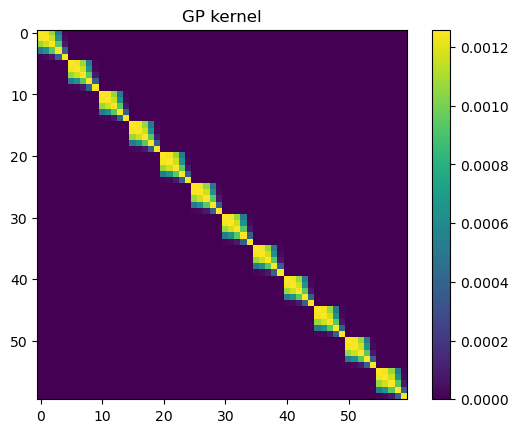

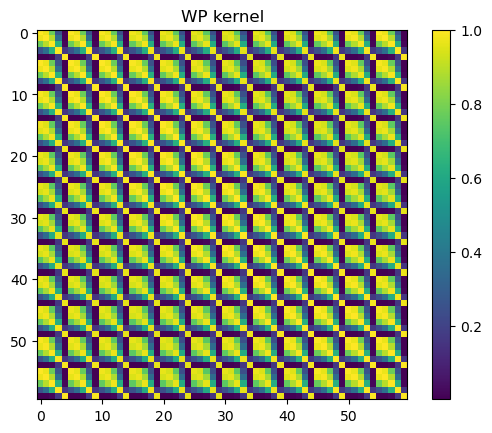

In [48]:
# Define kernels

periodic_gp_angle = lambda a, b: hyperparams["gamma_gp_angle"] * (a == b) + hyperparams["beta_gp_angle"] * jnp.exp(
    -jnp.sin(jnp.pi * jnp.abs(a - b) / PERIOD) ** 2 / hyperparams["lambda_gp_angle"]
)
square_gp_sf = lambda a, b: hyperparams["gamma_gp_sf"] * (a == b) + hyperparams["beta_gp_sf"] * jnp.exp(
    -(a - b) ** 2 / hyperparams["lambda_gp_sf"]
)
kernel_gp = lambda x, y: periodic_gp_angle(x[0], y[0]) * square_gp_sf(x[1], y[1])


gp = models.GaussianProcess(kernel=kernel_gp, N=N)


periodic_wp_angle = lambda a, b: hyperparams["gamma_wp_angle"] * (a == b) + hyperparams["beta_wp_angle"] * jnp.exp(
    -jnp.sin(jnp.pi * jnp.abs(a - b) / PERIOD) ** 2 / hyperparams["lambda_wp_angle"]
)
square_wp_sf = lambda a, b: hyperparams["gamma_wp_sf"] * (a == b) + hyperparams["beta_wp_sf"] * jnp.exp(
    -(a - b) ** 2 / hyperparams["lambda_wp_sf"]
)
kernel_wp = lambda x, y: periodic_wp_angle(x[0], y[0]) * square_wp_sf(x[1], y[1])

optimise_L = True
empirical = jnp.cov((y_tr-y_tr.mean(0)[None]).reshape(K*C,N).T)
V_Picked = empirical + wp_sample_diag * jnp.eye(N)
# V_Picked = empirical + 1e-3 * np.trace(empirical)/N * jnp.eye(N)    

wp = models.WishartLRDProcess(kernel=kernel_wp, P=int(hyperparams["p"]), V=V_Picked, optimize_L=True, diag_scale=DIAG_SCALE)
lik = models.NormalConditionalLikelihood(N)
joint = models.JointGaussianWishartProcess(gp, wp, lik)

plt.imshow(gp.evaluate_kernel(x_tr,x_tr))
plt.title('GP kernel')
plt.colorbar()
plt.show()
plt.imshow(wp.evaluate_kernel(x_tr,x_tr))
plt.title('WP kernel')
plt.colorbar()
plt.show()

# Run

In [49]:
init = {'G':y_tr.mean(0).T[:,None]}
varfam = inference.VariationalNormal(joint.model, init=init)
optimizer = optim.Adam(ADAM_OPT)
key = jax.random.PRNGKey(SEED)
varfam.infer(optimizer, x_tr.squeeze(), y_tr, n_iter=ITERATIONS, key=key, num_particles = NUM_PART)
joint.update_params(varfam.posterior)

/home/scastedo/wishart-process/inference.py:29: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  svi_result = svi.run(key, n_iter, x, y, stable_update=True)
  0%|          | 0/150000 [00:00<?, ?it/s]/home/scastedo/miniforge3/envs/wishart/lib/python3.13/site-packages/jax/_src/linear_util.py:370: UserWarning: Missing a plate statement for batch dimension -2 at site 'y'. You can use `numpyro.util.format_shapes` utility to check shapes at all sites of your model.
  ans = _fun(*args, **kwargs)
100%|██████████| 150000/150000 [34:55<00:00, 71.58it/s, init loss: 2401011246218.9277, avg. loss [142501-150000]: 100219.7493]


# Analyse

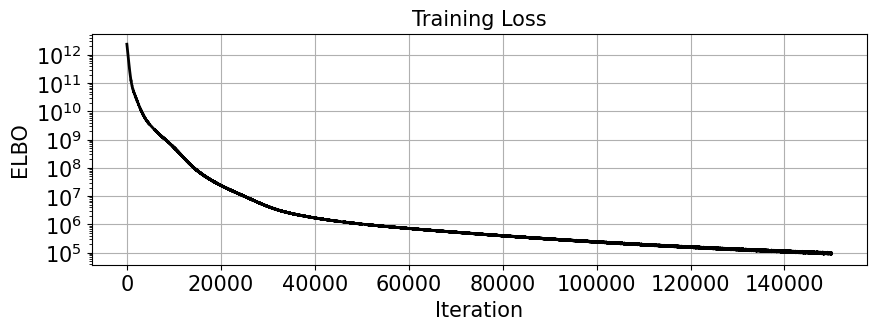

In [50]:
# %% Visualization
visualizations.plot_loss(
    [varfam.losses],xlabel='Iteration',ylabel='ELBO',titlestr='Training Loss',colors=['k'],
)
# plt.plot(varfam.losses)
# plt.yscale('log')
# plt.ylim(-1.5e5,20000)
# plt.xlim(20000,ITERATIONS)

In [51]:
NMC = 100
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)

# Held-out log-likelihood
def one_draw(rng):
    with numpyro.handlers.seed(rng_seed=rng):
        mu, Sigma, _ = posterior.sample(x_test)
    return lik.log_prob(y_test, mu, Sigma).mean()

mc_keys = jax.random.split(jax.random.PRNGKey(SEED), NMC)
print("Held-out mean log-lik:", float(jax.vmap(one_draw)(mc_keys).mean()))

Held-out mean log-lik: 109.14038382937457


(2, 60)


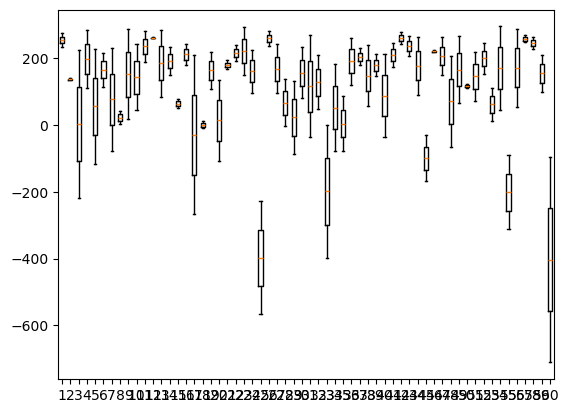

In [52]:
from numpyro import distributions as dist

NMC = 100
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)
# # Held-out log-likelihood
# def one_draw(rng):
#     with numpyro.handlers.seed(rng_seed=rng):
#         mu, Sigma, _ = posterior.sample(x_test)
#     return lik.log_prob(y_test, mu, Sigma).mean()

# mc_keys = jax.random.split(jax.random.PRNGKey(SEED), NMC)
# print("Held-out mean log-lik:", float(jax.vmap(one_draw)(mc_keys).mean()))

with numpyro.handlers.seed(rng_seed=jax.random.PRNGKey(SEED)):
    lp = posterior.log_prob(x_test, y_test)
print(lp.shape)
plt.boxplot(lp)

# Empirical held out log likeilihood
def empirical_loglik_per_condition(y_train, y_test, jitter=1e-6):
    """
    y_train: (K_train, C, N)
    y_test:  (K_test,  C, N)
    Returns:
      lp_test: (K_test, C) log-likelihood for each held-out trial/condition
      per_cond_mean: (C,) mean over trials for each condition
    """
    Kt, C, N = y_train.shape
    Kte = y_test.shape[0]

    mu = y_train.mean(axis=0)  # (C, N)
    sigma = np.zeros((C, N, N))
    for c in range(C):
        cov = np.cov(y_train[:, c, :], rowvar=False)
        sigma[c] = cov + jitter * np.eye(N)

    # compute loglik for each condition
    lp = []
    for c in range(C):
        mvn = dist.MultivariateNormal(loc=jnp.asarray(mu[c]), covariance_matrix=jnp.asarray(sigma[c]))
        lp_c = mvn.log_prob(jnp.asarray(y_test[:, c, :]))  # (K_test,)
        lp.append(lp_c)
    lp = jnp.stack(lp, axis=1)  # (K_test, C)

    return lp, lp.mean(axis=0)
lp_emp, emp_per_cond = empirical_loglik_per_condition(y_tr, y_test, jitter=1e-6)


(2, 60)


{'whiskers': [<matplotlib.lines.Line2D at 0x7f014866ee90>,
 'caps': [<matplotlib.lines.Line2D at 0x7f014866f110>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f014866ed50>,
 'medians': [<matplotlib.lines.Line2D at 0x7f014866f390>,
 'fliers': [<matplotlib.lines.Line2D at 0x7f014866f4d0>,
 'means': []}

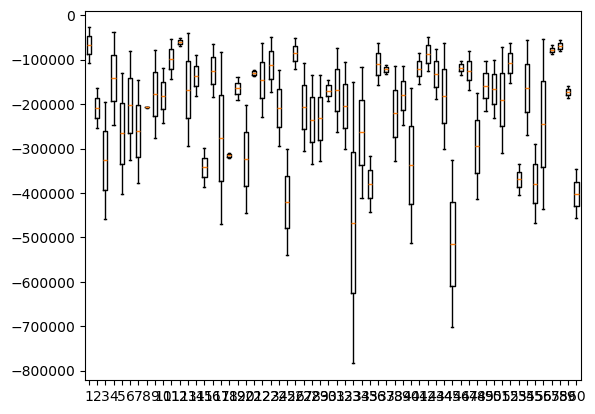

In [53]:
print(lp_emp.shape)
plt.boxplot(lp_emp)

In [24]:
per_trial = lp.mean(axis=1)      # average over conditions
per_cond  = lp.mean(axis=0)      # average over trials
global_mean = lp.mean()          # single scalar (can be big)

print("Global mean log-lik:", global_mean)

Global mean log-lik: 71.15477834391977


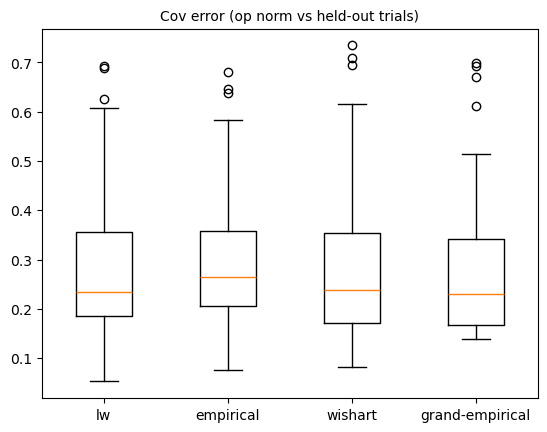

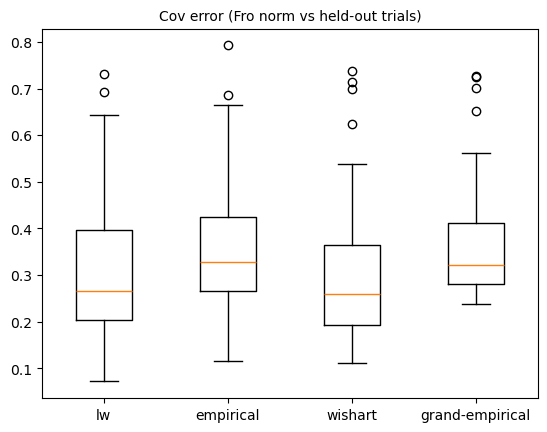

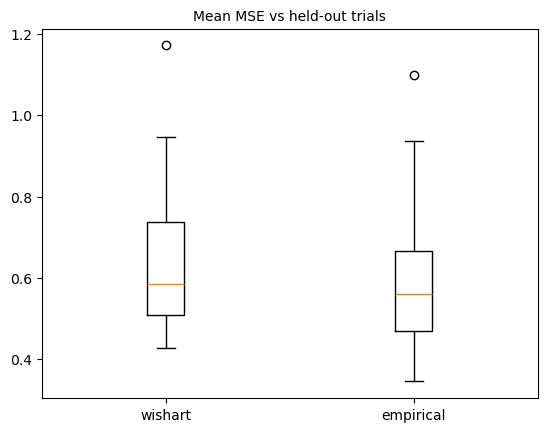

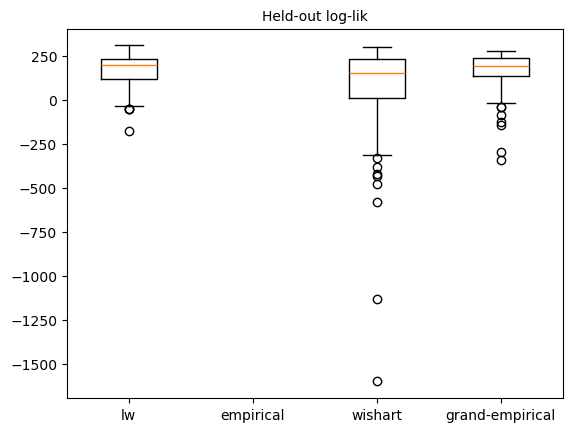

In [25]:
import jax.numpy as jnp
import evaluation
import visualizations
import numpyro

# posterior samples on training conditions
posterior = models.NormalGaussianWishartPosterior(joint, varfam, x_tr)
with numpyro.handlers.seed(rng_seed=SEED):
    mu_hat, sigma_hat, _ = posterior.sample(x_tr)  # mu_hat: C x N, sigma_hat: C x N x N

# held-out trials (same conditions)
y_trials = y_te["x"]  # K_test x C_train x N

# empirical cov from held-out trials
sigma_emp_trials = evaluation.compare(y_trials)["empirical"]  # N x N x C

# baselines from training trials
compared = evaluation.compare(y_tr)
compared["wishart"] = sigma_hat.transpose(1, 2, 0)

# optional grand-empirical baseline
y_flat = y_tr.reshape(-1, y_tr.shape[-1])
grand = jnp.cov(y_flat.T)
compared["grand-empirical"] = jnp.repeat(grand[:, :, None], y_tr.shape[1], axis=2)

# covariance error (operator + Frobenius)
perf_op = evaluation.evaluate(compared, sigma_emp_trials, ord=2)
perf_fro = evaluation.evaluate(compared, sigma_emp_trials, ord="fro")
visualizations.plot_box(perf_op, titlestr="Cov error (op norm vs held-out trials)")
visualizations.plot_box(perf_fro, titlestr="Cov error (Fro norm vs held-out trials)")

# mean MSE vs held-out trials
mse = lambda a, b: jnp.sqrt(((a - b) ** 2).sum(-1))
mu_emp_trials = y_trials.mean(0)
perf_mean = {
    "wishart": mse(mu_hat, mu_emp_trials),
    "empirical": mse(y_tr.mean(0), mu_emp_trials),
}
visualizations.plot_box(perf_mean, titlestr="Mean MSE vs held-out trials")

# held-out log-likelihood
lpp = {}
mu_emp = y_tr.mean(0)
for key in compared:
    lpp[key] = lik.log_prob(y_trials, mu_emp, compared[key].transpose(2, 0, 1)).flatten()
lpp["wishart"] = lik.log_prob(y_trials, mu_hat, sigma_hat).flatten()
visualizations.plot_box(lpp, titlestr="Held-out log-lik")


/home/scastedo/wishart-process/visualizations.py:63: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


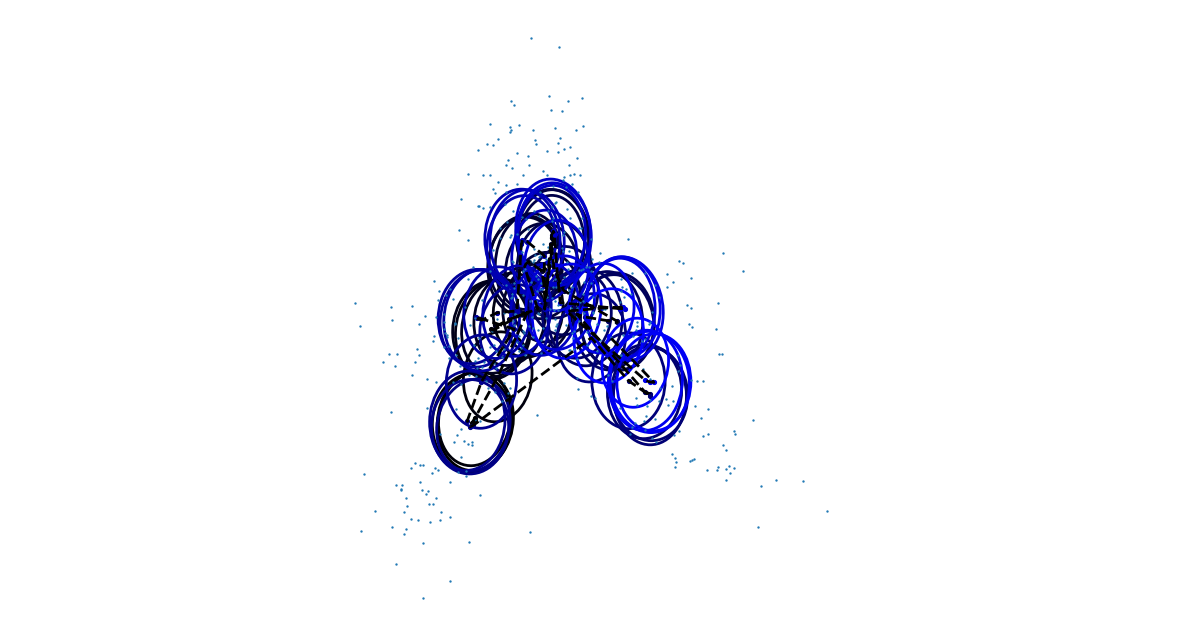

In [54]:
# Create the posterior distribution instance and sample from it in train and test conditions and plot it
posterior = models.NormalGaussianWishartPosterior(joint,varfam,x_tr)
with numpyro.handlers.seed(rng_seed=SEED):
    mu_hat, sigma_hat, F_hat = posterior.sample(x_tr)
    # mu_prime, sigma_prime = posterior.derivative(x_tr)

with numpyro.handlers.seed(rng_seed=SEED):
    mu_test_hat, sigma_test_hat, F_test_hat = posterior.sample(x_test)
    # mu_test_prime, sigma_test_prime = posterior.derivative(x_test)

visualizations.visualize_pc(
    mu_hat[:,None],sigma_hat,
    pc=y_tr.reshape(y_tr.shape[0]*y_tr.shape[1],-1),
    std = 1
)

(60, 137)


/home/scastedo/wishart-process/visualizations.py:63: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


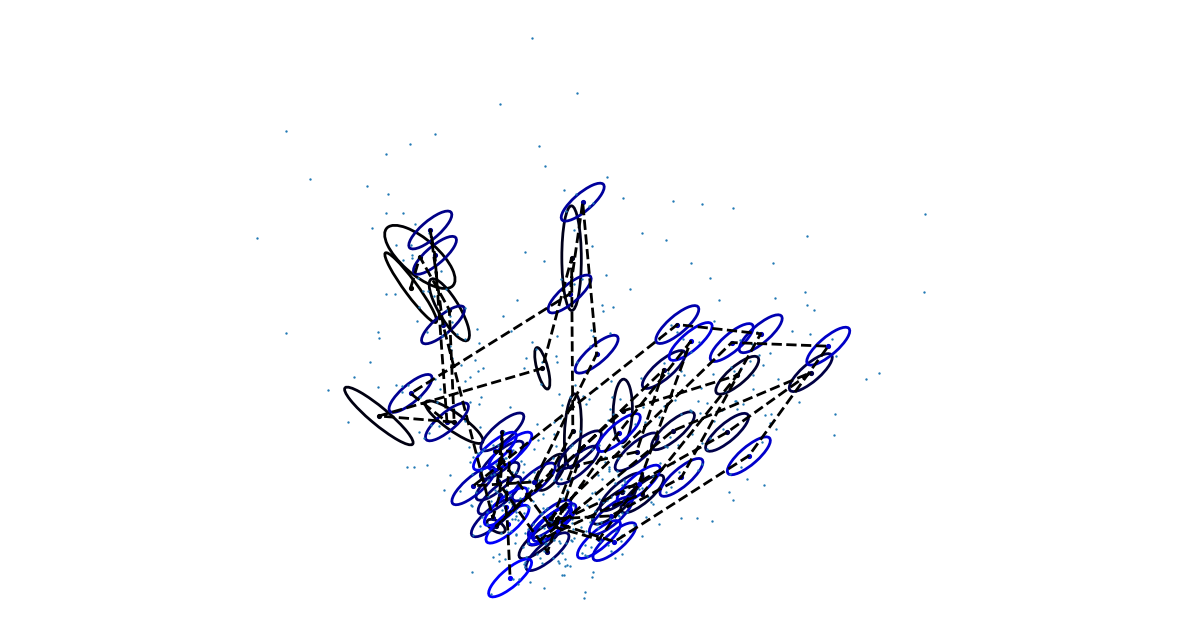

In [55]:
# EMPIRICAL ANALYSIS
import pandas as pd
empirical_mu = jnp.nanmean(y_tr,axis=0)
print(empirical_mu.shape)
# empirical_cov =jnp.cov(TEST_RESPONSE,axis=0)
empirical_sigma = jnp.zeros((C1, N, N))
for i in range(C1):
    dat = y_tr[:,i,:] # Shape K x N
    df = pd.DataFrame(dat)
    covariances = df.cov().to_numpy()
    covariances += np.eye(N) * 1e-12
    empirical_sigma = empirical_sigma.at[i].set(covariances)
visualizations.visualize_pc(
    empirical_mu[:,None],empirical_sigma,pc=y_tr.reshape(y_tr.shape[0]*y_tr.shape[1],-1),
    std = 0.5
)

(60, 137)
(60, 2)
[0.   0.02]
[ 0  5 10 15 20 25 30 35 40 45 50 55]


/home/scastedo/wishart-process/visualizations.py:63: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


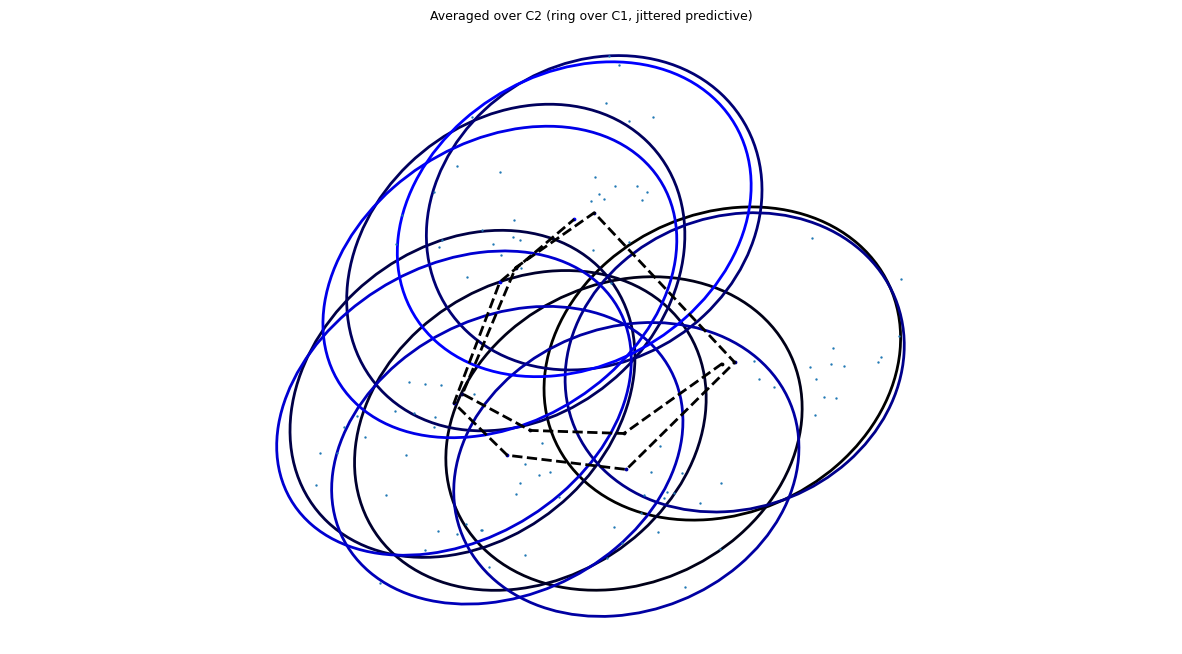

In [56]:
print(mu_hat.shape)
print(x_tr.shape)
print(x_tr[0,:])
# indices in xfull where first index is -1
indices = jnp.where(x_tr[:,1] == ((0.02)))[0]
print(indices)
mu_ring = mu_hat[indices,:]
sigma_ring = sigma_hat[indices,:,:]
Y_RING = y_tr[:,indices,:]#.reshape(K*C1,-1)


visualizations.visualize_pc(
    mu_ring[:,None],
    sigma_ring,
    pc=Y_RING.reshape(K*C1,-1),
    title_str="Averaged over C2 (ring over C1, jittered predictive)",
    dotsize=12,
)

(12, 137)


/home/scastedo/wishart-process/visualizations.py:63: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


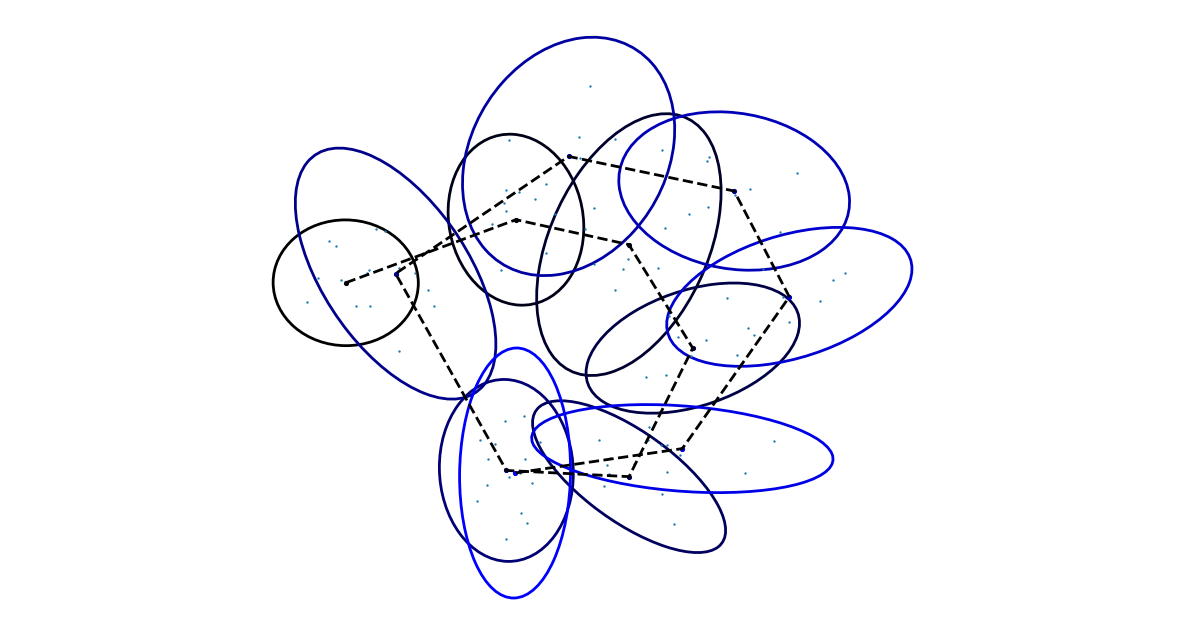

In [52]:
# EMPIRICAL ANALYSIS
import pandas as pd
empirical_mu = jnp.nanmean(Y_RING,axis=0)
print(empirical_mu.shape)
# empirical_cov =jnp.cov(TEST_RESPONSE,axis=0)
empirical_sigma = jnp.zeros((C1, N, N))
for i in range(C1):
    dat = Y_RING[:,i,:] # Shape K x N
    df = pd.DataFrame(dat)
    covariances = df.cov().to_numpy()
    covariances += np.eye(N) * 1e-12
    empirical_sigma = empirical_sigma.at[i].set(covariances)
visualizations.visualize_pc(
    empirical_mu[:,None],empirical_sigma,pc=Y_RING.reshape(Y_RING.shape[0]*Y_RING.shape[1],-1)
)


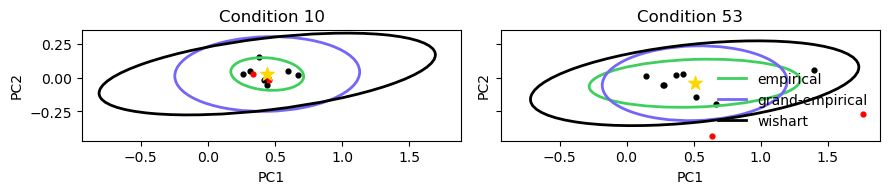

In [119]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse

# Inputs
y_train = np.asarray(y_tr)
y_test_trials = np.asarray(y_te["x"] if isinstance(y_te, dict) else y_te)
sigma_hat = np.asarray(sigma_hat)

cond_ids = np.random.choice(y_train.shape[1], size=2, replace=False) #[0, 24]  # adjust (Condition 1 and 25)
n_std = 2.0

# PCA on all train+test points in training conditions
# all_pts = np.concatenate([y_train, y_test_trials], axis=0).reshape(-1, y_train.shape[-1])
# pca = PCA(n_components=2).fit(all_pts)


train_res = y_train - y_train.mean(0, keepdims=True)
test_res  = y_test_trials - y_train.mean(0, keepdims=True)
all_res   = np.concatenate([train_res, test_res], axis=0).reshape(-1, N)
pca = PCA(n_components=2).fit(all_res)

def proj(x):
    return pca.transform(x)

def cov_to_pc(cov):
    return pca.components_ @ cov @ pca.components_.T

def add_cov_ellipse(mu, cov, ax, n_std=2.0, **kwargs):
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * n_std * np.sqrt(vals)
    ell = Ellipse(mu, width, height, angle=angle, fill=False, **kwargs)
    ax.add_patch(ell)

# Grand empirical covariance (pooled residuals, condition-mean removed)
y_centered = y_train - y_train.mean(0, keepdims=True)
grand_cov = np.cov(y_centered.reshape(-1, y_train.shape[-1]), rowvar=False)

colors = {
    "empirical": "#3fcf5e",
    "grand": "#7566fa",   # tweak to match panel B
    "wishart": "#000000", # tweak to match panel B
}

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=True, sharey=True)
for ax, cond in zip(axes, cond_ids):
    train_pts = proj(y_train[:, cond, :])
    test_pts = proj(y_test_trials[:, cond, :])

    ax.scatter(train_pts[:, 0], train_pts[:, 1], s=12, c="k", label="train" if cond == cond_ids[0] else None)
    ax.scatter(test_pts[:, 0], test_pts[:, 1], s=12, c="r", label="test" if cond == cond_ids[0] else None)
    
    mu_emp = y_train[:, cond, :].mean(0)
    mu_pc = proj(mu_emp[None, :])[0]
    ax.scatter(mu_pc[0], mu_pc[1], s=100, c="gold", marker="*", label="mean" if cond == cond_ids[0] else None)

    cov_emp = np.cov(y_train[:, cond, :], rowvar=False)
    cov_wish = sigma_hat[cond]

    add_cov_ellipse(mu_pc, cov_to_pc(cov_emp), ax, n_std=n_std, color=colors["empirical"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(grand_cov), ax, n_std=n_std, color=colors["grand"], lw=2)
    add_cov_ellipse(mu_pc, cov_to_pc(cov_wish), ax, n_std=n_std, color=colors["wishart"], lw=2)

    ax.set_title(f"Condition {cond + 1}")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_aspect("equal", adjustable="box")
handles = [plt.Line2D([0], [0], color=colors[k], lw=2) for k in colors]
labels = ["empirical", "grand-empirical", "wishart"]
axes[1].legend(handles, labels, frameon=False, loc="lower right")
# axes[0].legend(frameon=False, loc="upper right")
plt.tight_layout()
plt.show()


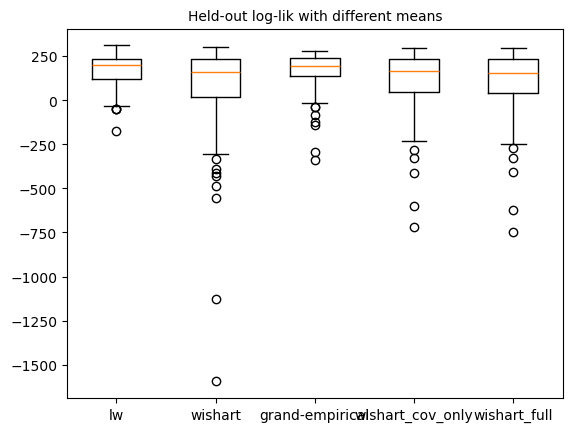

In [65]:
mu_emp = y_tr.mean(0)  # C x N

lpp = {}
for key in compared:
    if key == "empirical":
        continue
    lpp[key] = lik.log_prob(y_trials, mu_emp, compared[key].transpose(2,0,1)).flatten()

# Wishart covariance-only
lpp["wishart_cov_only"] = lik.log_prob(y_trials, mu_emp, sigma_hat).flatten()

# Wishart full predictive (as you currently do)
lpp["wishart_full"] = lik.log_prob(y_trials, mu_hat, sigma_hat).flatten()

visualizations.plot_box(lpp, titlestr="Held-out log-lik with different means")

Best overall mean log-likelihood: 151.6605492150752
Best lambdas: {'gp_angle': 0.0011857834607487175, 'gp_sf': 0.021617927264303824, 'wp_angle': 24.754599113289856, 'wp_sf': 0.014220205845903605}


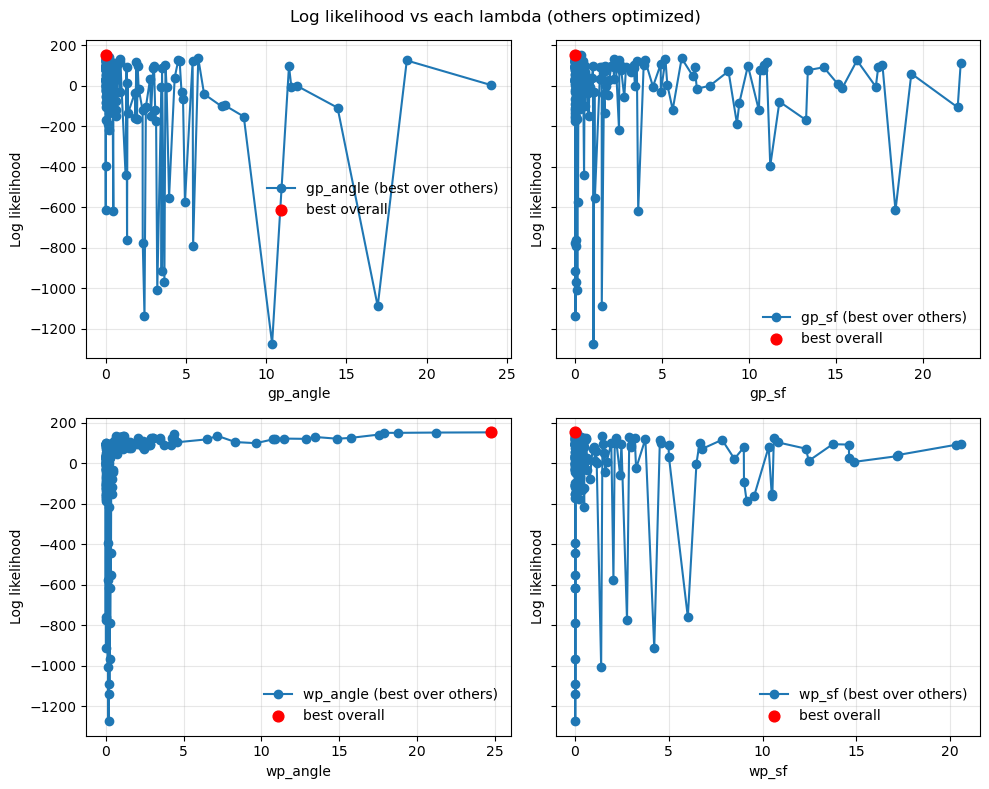

In [66]:
import json
import numpy as np
import matplotlib.pyplot as plt

# ---- load + merge ----
paths = [
    # "outputs/hyperparam_cv_results.json",  # change
    # "outputs/hyperparam_cv_results_lec.json",  # change
    # "outputs/hyperparam_cv_results3.json",  # change
    # "outputs/hyperparam_cv_results3lec.json",  # change
    "outputs/hyperparam_cv_results_feb_gonz_further.json",
    "outputs/hyperparam_cv_results_lecona_feb_further.json",
]

all_entries = []
for p in paths:
    with open(p, "r") as f:
        data = json.load(f)
    entries = data["lambda_sweep"]["entries"]
    all_entries.extend(entries)

# (optional) filter to p=0 only
all_entries = [e for e in all_entries if int(e.get("p", 0)) == 0]

# ---- find best overall ----
best_entry = max(all_entries, key=lambda e: e["mean"])
best_mean = best_entry["mean"]
best_lams = best_entry["lambdas"]

print("Best overall mean log-likelihood:", best_mean)
print("Best lambdas:", best_lams)

# ---- plot settings ----
lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    # group by value of this lambda, taking best mean across all other lambdas
    grouped = {}
    for e in all_entries:
        val = float(e["lambdas"][key])
        grouped.setdefault(val, []).append(e["mean"])
    xs = sorted(grouped.keys())
    ys = [max(grouped[x]) for x in xs]  # best (fixed-others) mean for each value
    
    ax.plot(xs, ys, marker="o", label=f"{key} (best over others)")
    # best overall as scatter
    ax.scatter([best_lams[key]], [best_mean], color="red", s=60, zorder=5, label="best overall")
    ax.set_xlabel(key)
    ax.set_ylabel("Log likelihood")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False)

fig.suptitle("Log likelihood vs each lambda (others optimized)")
plt.tight_layout()
plt.show()


Best overall mean log-likelihood: 151.6605492150752
Best lambdas: {'gp_angle': 0.0011857834607487175, 'gp_sf': 0.021617927264303824, 'wp_angle': 24.754599113289856, 'wp_sf': 0.014220205845903605}


KeyboardInterrupt: 

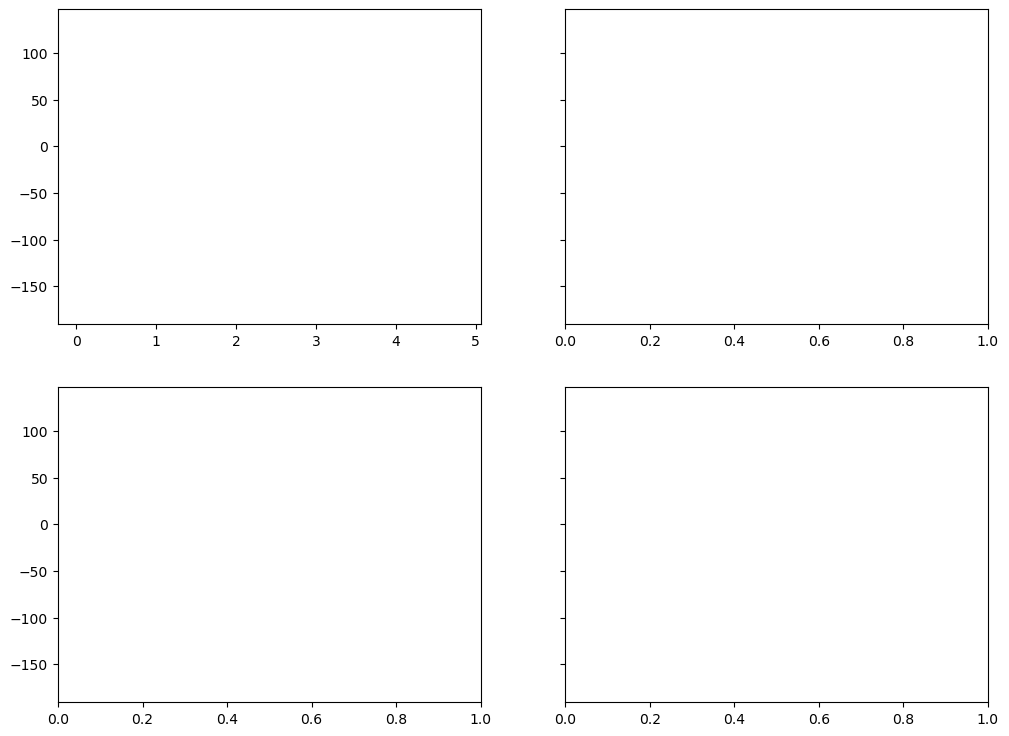

In [9]:
import json
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

# ---- load + merge ----
paths = [
    # "outputs/hyperparam_cv_results_feb_gonz.json",  # change
    # "outputs/hyperparam_cv_results_lecuona_large_feb6.json",  # change
    "outputs/hyperparam_cv_results_feb_gonz_further.json",
    "outputs/hyperparam_cv_results_lecona_feb_further.json",
]

all_entries = []
for p in paths:
    with open(p, "r") as f:
        data = json.load(f)
    all_entries.extend(data["lambda_sweep"]["entries"])

# filter to p=0 only (optional)
all_entries = [e for e in all_entries if int(e.get("p", 0)) == 0]

# ---- collect lambda grids ----
lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
grid = {k: sorted({float(e["lambdas"][k]) for e in all_entries}) for k in lambda_keys}

# map entry by lambdas for fast lookup
entry_map = {}
for e in all_entries:
    key = tuple(float(e["lambdas"][k]) for k in lambda_keys)
    entry_map[key] = e

# ---- best overall ----
best_entry = max(all_entries, key=lambda e: e["mean"])
best_mean = best_entry["mean"]
best_lams = best_entry["lambdas"]

print("Best overall mean log-likelihood:", best_mean)
print("Best lambdas:", best_lams)

# ---- plot: for each lambda, all possible combinations of other three ----
fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharey=True)
axes = axes.ravel()

for ax, target_key in zip(axes, lambda_keys):
    other_keys = [k for k in lambda_keys if k != target_key]
    other_grids = [grid[k] for k in other_keys]

    # for each combination of the other 3 lambdas, plot curve vs target lambda
    for others in product(*other_grids):
        xs, ys = [], []
        for val in grid[target_key]:
            lams = {
                target_key: val,
                other_keys[0]: others[0],
                other_keys[1]: others[1],
                other_keys[2]: others[2],
            }
            key = tuple(lams[k] for k in lambda_keys)
            if key in entry_map:
                xs.append(val)
                ys.append(entry_map[key]["mean"])
        if len(xs) > 0:
            ax.plot(xs, ys, alpha=0.6, linewidth=1)

    # best overall as scatter
    ax.scatter([best_lams[target_key]], [best_mean], color="red", s=60, zorder=5, label="best overall")

    ax.set_xlabel(target_key)
    ax.set_ylim(0,None)
    ax.set_ylabel("Log likelihood")
    ax.grid(True, alpha=0.3)

# add single legend for best point
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper right")

fig.suptitle("All combinations: log likelihood vs each lambda")
plt.tight_layout()
plt.show()


In [6]:
import json

files = [
    # "outputs/hyperparam_cv_results_feb_gonz_further.json",  # change
    # "outputs/hyperparam_cv_results_lecona_feb_further.json",  # change
    "outputs/hyperparam_cv_results_feb_12_lec.json",  # change
    "outputs/hyperparam_cv_results_feb_12.json",  #
]


entries = []
for f in files:
    with open(f, "r") as fh:
        data = json.load(fh)
    entries.extend(data["lambda_sweep"]["entries"])

# Best overall (by mean)
best = max(entries, key=lambda e: e["mean"])

print("Best overall mean:", best["mean"])
print("Best lambdas:", best["lambdas"])
print("Best p:", best["p"])

# (optional) top 5
top5 = sorted(entries, key=lambda e: e["mean"], reverse=True)[:5]
print("\nTop 5:")
for i, e in enumerate(top5, 1):
    print(f"{i}) mean={e['mean']:.4f}, p={e['p']}, lambdas={e['lambdas']}")


Best overall mean: 161.61137086509612
Best lambdas: {'gp_angle': 23.900086739014753, 'gp_sf': 5.192837570168593, 'wp_angle': 41.422415818841266, 'wp_sf': 3.732903794927424}
Best p: 0

Top 5:
1) mean=161.6114, p=0, lambdas={'gp_angle': 23.900086739014753, 'gp_sf': 5.192837570168593, 'wp_angle': 41.422415818841266, 'wp_sf': 3.732903794927424}
2) mean=161.4334, p=0, lambdas={'gp_angle': 4.315845014182919, 'gp_sf': 7.484036925643329, 'wp_angle': 32.42871536223023, 'wp_sf': 1.6188329801660264}
3) mean=161.3518, p=0, lambdas={'gp_angle': 20.939256437766478, 'gp_sf': 19.401022643314903, 'wp_angle': 16.976439246145702, 'wp_sf': 3.7150698880698214}
4) mean=161.0976, p=0, lambdas={'gp_angle': 17.051827160576632, 'gp_sf': 0.5026421420765976, 'wp_angle': 42.22781430871199, 'wp_sf': 3.39753602384208}
5) mean=160.4055, p=0, lambdas={'gp_angle': 12.228850192030556, 'gp_sf': 21.756379345524035, 'wp_angle': 19.475541944982105, 'wp_sf': 0.6560144968568429}


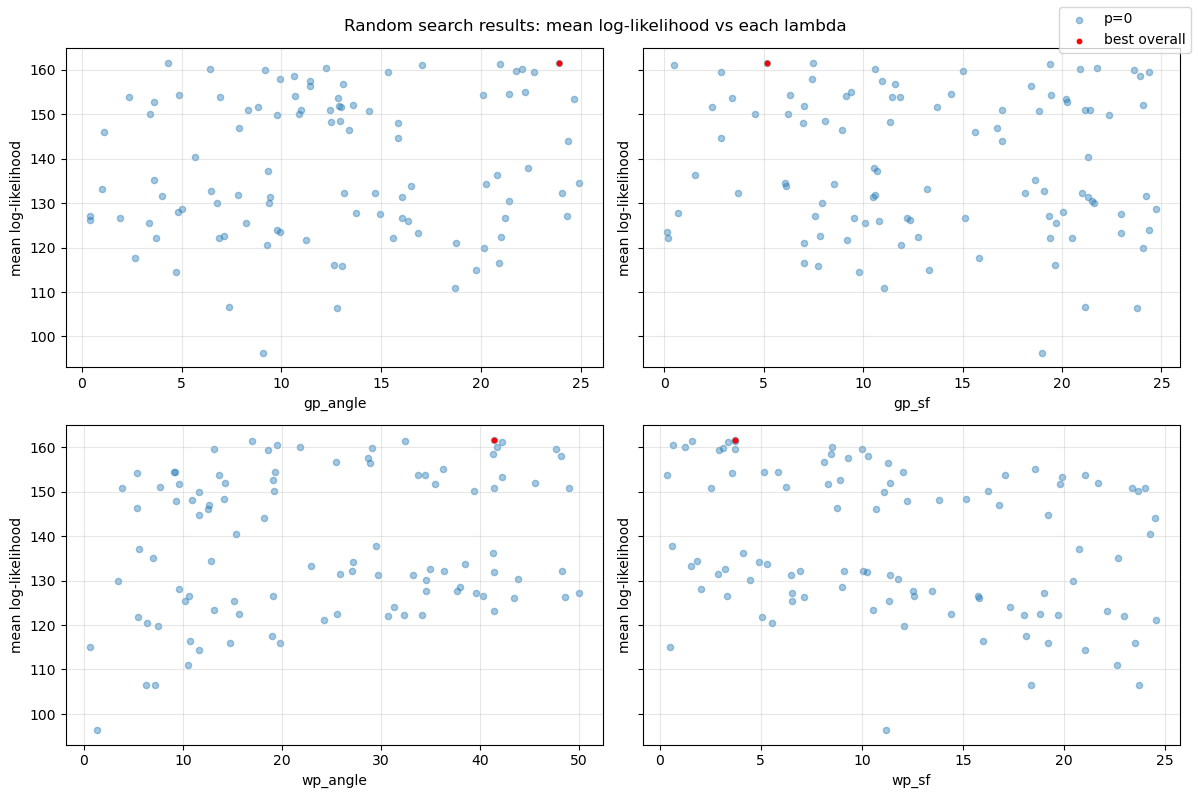

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt


entries = []
for f in files:
    with open(f, "r") as fh:
        data = json.load(fh)
    entries.extend(data["lambda_sweep"]["entries"])

# best overall
best = max(entries, key=lambda e: e["mean"])

lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
ps = sorted({int(e["p"]) for e in entries})

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()
#keep only p=0 
ps = [0]
for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs = [e["lambdas"][key] for e in entries if int(e["p"]) == p]
        ys = [e["mean"] for e in entries if int(e["p"]) == p]
        ax.scatter(xs, ys, alpha=0.4, s=20, label=f"p={p}")
    ax.scatter([best["lambdas"][key]], [best["mean"]], color="red", s=10, label="best overall")
    # ax.set_xscale("log")  # log x helps see range
    ax.set_xlabel(key)
    ax.set_ylabel("mean log-likelihood")
    # ax.set_ylim(0,None)
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Random search results: mean log-likelihood vs each lambda")
plt.tight_layout()
plt.show()


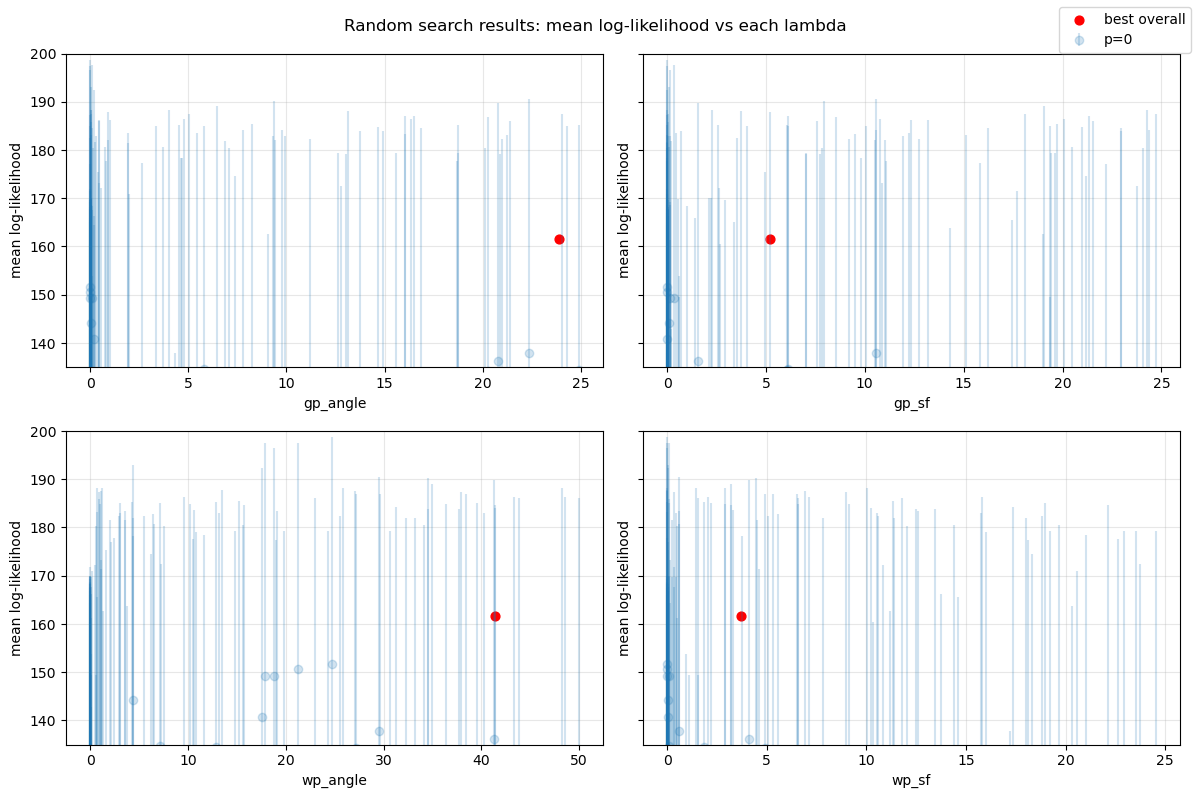

In [14]:
import numpy as np
import matplotlib.pyplot as plt

lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
ps = [0]  # or [0] if you want only p=0

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs, ys, yerr = [], [], []
        for e in entries:
            if int(e["p"]) != p:
                continue
            xs.append(e["lambdas"][key])
            ys.append(e["mean"])
            # std across folds using fold score_mean
            fold_means = [f["score_mean"] for f in e["folds"]]
            yerr.append(np.std(fold_means))

        ax.errorbar(xs, ys, yerr=yerr, fmt="o", alpha=0.2, label=f"p={p}")

    ax.scatter([best["lambdas"][key]], [best["mean"]],
               color="red", s=40, label="best overall")

    ax.set_xlabel(key)
    ax.set_ylabel("mean log-likelihood")
    ax.set_ylim(135, 200)
    ax.grid(True, alpha=0.3)
    # ax.set_xscale('log')

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Random search results: mean log-likelihood vs each lambda")
plt.tight_layout()
plt.show()


Top-10% cutoff: 116.312, kept 75 / 750


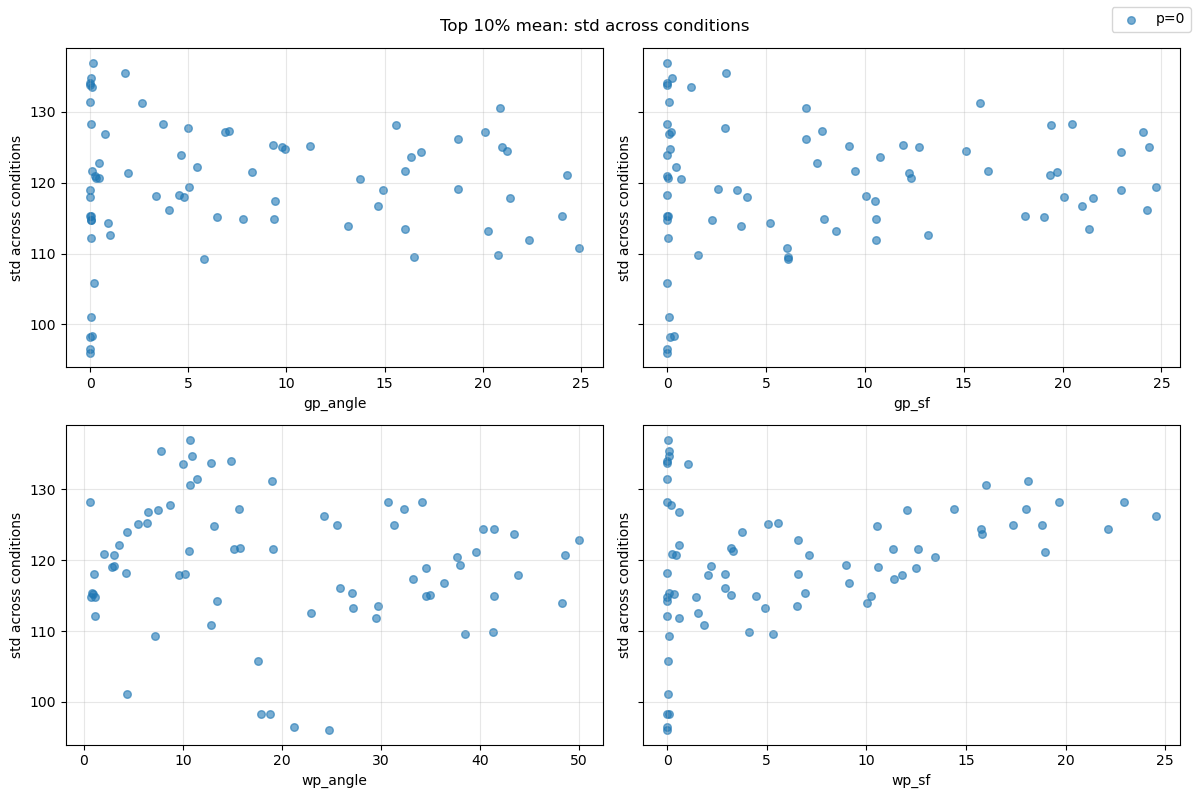

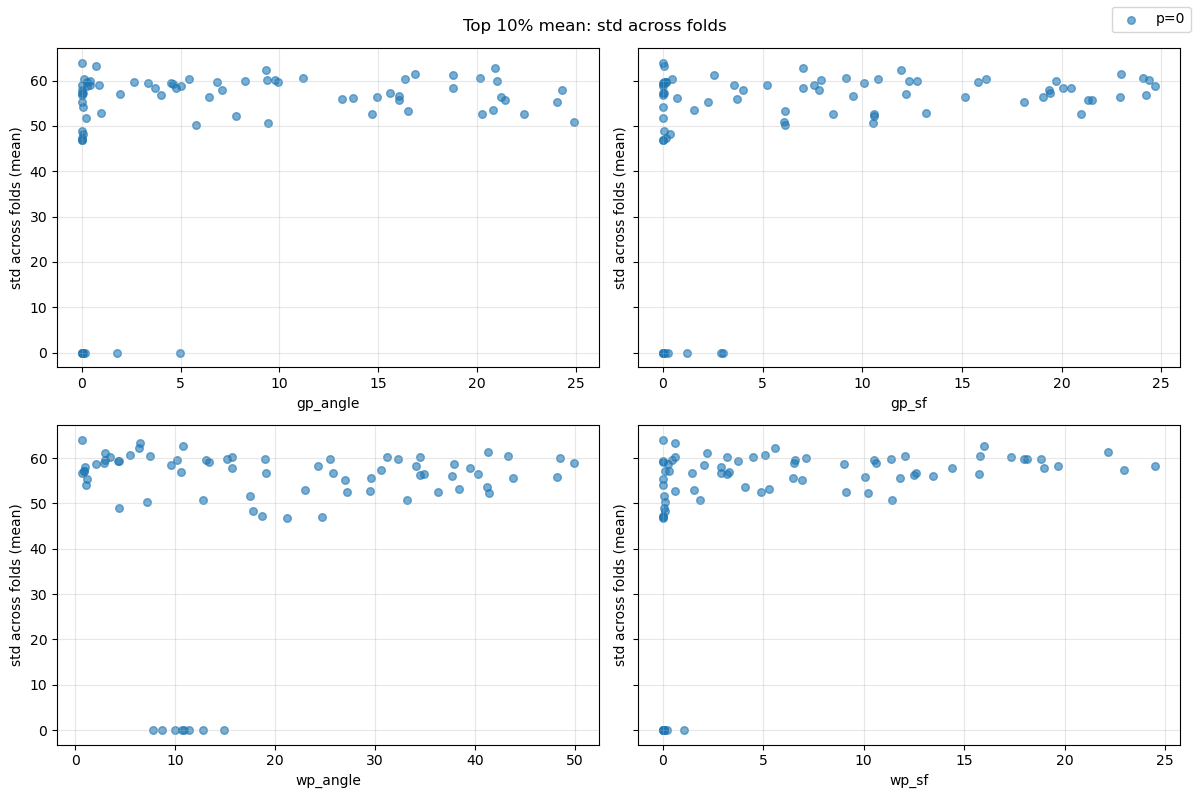


Top 5 smallest std across conditions (among top 10% mean):
1) mean=151.6605, std_cond=96.0079, p=0, lambdas={'gp_angle': 0.0011857834607487175, 'gp_sf': 0.021617927264303824, 'wp_angle': 24.754599113289856, 'wp_sf': 0.014220205845903605}
2) mean=150.6571, std_cond=96.4793, p=0, lambdas={'gp_angle': 0.008505849447602744, 'gp_sf': 0.004037720938767501, 'wp_angle': 21.20670389615672, 'wp_sf': 0.0010282099218907358}
3) mean=149.2604, std_cond=98.2684, p=0, lambdas={'gp_angle': 0.0011845297326264024, 'gp_sf': 0.14814879063858255, 'wp_angle': 18.751306595479377, 'wp_sf': 0.018007729184827112}
4) mean=149.2548, std_cond=98.3311, p=0, lambdas={'gp_angle': 0.07358094837213738, 'gp_sf': 0.340342949192894, 'wp_angle': 17.837057961401655, 'wp_sf': 0.10342045073520482}
5) mean=144.1412, std_cond=101.0924, p=0, lambdas={'gp_angle': 0.023518846561802396, 'gp_sf': 0.07273849762095898, 'wp_angle': 4.367031782417285, 'wp_sf': 0.0630424747767605}
6) mean=140.7425, std_cond=105.8113, p=0, lambdas={'gp_an

In [44]:
import json
import numpy as np
import matplotlib.pyplot as plt

files = [
    "outputs/hyperparam_cv_results_feb_gonz_further.json",
    "outputs/hyperparam_cv_results_lecona_feb_further.json",
    "outputs/hyperparam_cv_results_feb_12_lec.json",
    "outputs/hyperparam_cv_results_lecuona_large_feb6.json",
]

entries = []
for f in files:
    with open(f, "r") as fh:
        data = json.load(fh)
    entries.extend(data["lambda_sweep"]["entries"])

# ---- decision rule: top 10% by mean ----
means = np.array([e["mean"] for e in entries])
cutoff = np.percentile(means, 90)
top_entries = [e for e in entries if e["mean"] >= cutoff]

print(f"Top-10% cutoff: {cutoff:.3f}, kept {len(top_entries)} / {len(entries)}")

# ---- helper: std across conditions ----
# We compute per-fold std across conditions:
#   lp: K_test x C
#   per_cond = mean over trials -> shape (C,)
#   std_cond = std(per_cond)
# Then average across folds for the entry.
def std_across_conditions(entry):
    stds = []
    for f in entry["folds"]:
        lp = f.get("score_lp", None)
        if lp is None:
            continue
        lp = np.asarray(lp)
        if lp.ndim != 2:
            continue
        per_cond = lp.mean(axis=0)
        stds.append(per_cond.std())
    return float(np.mean(stds)) if stds else np.nan

# ---- helper: std across folds (means) ----
def std_across_folds(entry):
    fold_means = [f["score_mean"] for f in entry["folds"]]
    return float(np.std(fold_means)) if fold_means else np.nan

# precompute stats
for e in top_entries:
    e["std_conditions"] = std_across_conditions(e)
    e["std_folds"] = std_across_folds(e)

lambda_keys = ["gp_angle", "gp_sf", "wp_angle", "wp_sf"]
ps = sorted({int(e["p"]) for e in entries})

# ---- plot 1: std across conditions (top 10%) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs = [e["lambdas"][key] for e in top_entries if int(e["p"]) == p]
        ys = [e["std_conditions"] for e in top_entries if int(e["p"]) == p]
        ax.scatter(xs, ys, alpha=0.6, s=30, label=f"p={p}")
    # ax.set_xscale("log")
    ax.set_xlabel(key)
    ax.set_ylabel("std across conditions")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top 10% mean: std across conditions")
plt.tight_layout()
plt.show()

# ---- plot 2: std across folds (top 10%) ----
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()

for ax, key in zip(axes, lambda_keys):
    for p in ps:
        xs = [e["lambdas"][key] for e in top_entries if int(e["p"]) == p]
        ys = [e["std_folds"] for e in top_entries if int(e["p"]) == p]
        ax.scatter(xs, ys, alpha=0.6, s=30, label=f"p={p}")
    # ax.set_xscale("log")
    ax.set_xlabel(key)
    ax.set_ylabel("std across folds (mean)")
    ax.grid(True, alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
fig.suptitle("Top 10% mean: std across folds")
plt.tight_layout()
plt.show()

#print of the top entries print the top 5 smallest std across conditions among the top 10% mean entries
top_entries_sorted = sorted(top_entries, key=lambda e: e["std_conditions"])
print("\nTop 5 smallest std across conditions (among top 10% mean):")
for i, e in enumerate(top_entries_sorted[:10], 1):
    print(f"{i}) mean={e['mean']:.4f}, std_cond={e['std_conditions']:.4f}, p={e['p']}, lambdas={e['lambdas']}")

# print the top 5 smallest std across folds among the top 10% mean entries
top_entries_sorted_folds = sorted(top_entries, key=lambda e: e["std_folds"])
print("\nTop 5 smallest std across folds (among top 10% mean):")
for i, e in enumerate(top_entries_sorted_folds[:10], 1):
    print(f"{i}) mean={e['mean']:.4f}, std_folds={e['std_folds']:.4f}, p={e['p']}, lambdas={e['lambdas']}")



# Smallest condition std for entries with fold std<1
filtered = [e for e in top_entries if e["std_folds"] < 1.0]
filtered_sorted = sorted(filtered, key=lambda e: e["std_conditions"])
print("\nTop 5 smallest std across conditions (fold std < 1):")
for i, e in enumerate(filtered_sorted[:10], 1):
    print(f"{i}) mean={e['mean']:.4f}, std_cond={e['std_conditions']:.4f}, std_folds={e['std_folds']:.4f}, p={e['p']}, lambdas={e['lambdas']}")

# Compare covariance to emprircal

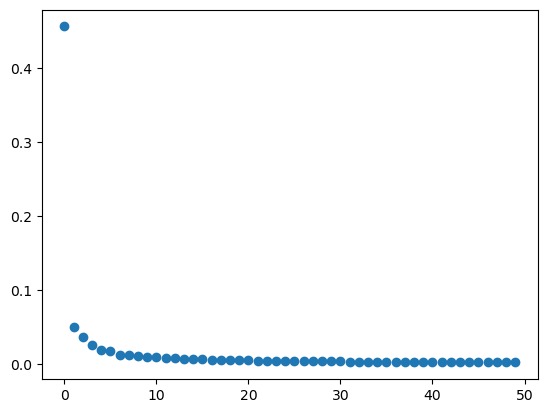

In [67]:
evals_store = np.zeros((12,50))
for iangle in range(12):
    cov_matrix = sigma_ring[iangle,:,:]
    eval, evec = np.linalg.eigh(cov_matrix)
    non_zero_evals = eval[::-1]
    evals_store[iangle,:] = non_zero_evals[:50]
    # plt.scatter(np.arange(len(non_zero_evals)), non_zero_evals)
    # plt.title(f'Angle {iangle}')
    # plt.show()
average_evals = np.mean(evals_store, axis=0)
plt.scatter(np.arange(len(average_evals)), average_evals)





(0.0, 10.0)

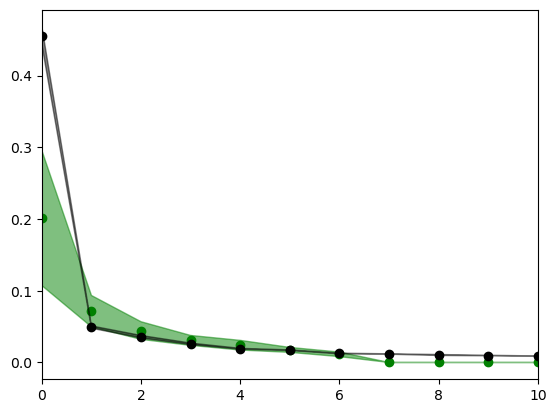

In [68]:
raw_evals_store = np.zeros((12,50))
for iangle in range(12):
    test = Y_RING[:,iangle,:]  # shape (K, N)
    covariance_matrix = np.cov(test, rowvar=False)  # shape (N, N)
    eval, evec = np.linalg.eigh(covariance_matrix)
    non_zero_evals = eval[::-1]
    raw_evals_store[iangle,:] = non_zero_evals[:50]
average_raw_evals = np.mean(raw_evals_store, axis=0)#[1:]
y_error_raw = np.std(raw_evals_store, axis=0) #/ np.sqrt(raw_evals_store.shape[0])
y_error_model = np.std(evals_store, axis=0)# / np.sqrt(evals_store.shape[0])
plt.scatter(np.arange(len(average_raw_evals)), average_raw_evals, color = 'green')
plt.fill_between(np.arange(len(average_raw_evals)), average_raw_evals - y_error_raw, average_raw_evals + y_error_raw, alpha=0.5, label='Raw Evals Std Dev', color = 'green')
plt.scatter(np.arange(len(average_evals)), average_evals, color = 'black')
plt.fill_between(np.arange(len(average_evals)), average_evals - y_error_model, average_evals + y_error_model, alpha=0.5, label='Model Evals Std Dev', color = 'black')
# plt.ylim(0,0.25)
plt.xlim(0,10)


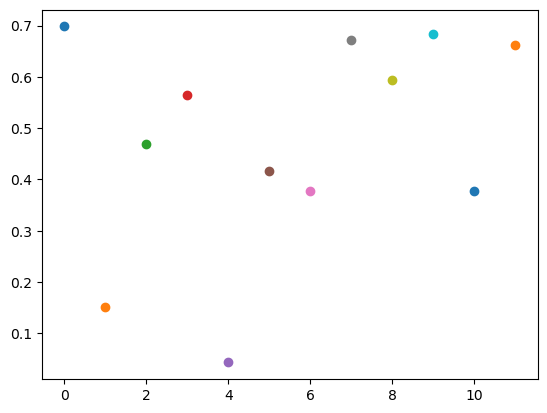

In [69]:
# overlaps between top empirical and model eigenvectors for each angle
raw_evals_store = np.zeros((12,50))
for iangle in range(12):
    test = Y_RING[:,iangle,:]  # shape (K, N)
    covariance_matrix_data = np.cov(test, rowvar=False)  # shape (N, N)
    covariance_matrix_model = sigma_ring[iangle,:,:]
    _,evec_data = np.linalg.eigh(covariance_matrix_data)
    _,evec_model = np.linalg.eigh(covariance_matrix_model)

    overlap = np.dot(evec_data[:,-1], evec_model[:,-1])**2
    plt.scatter(iangle, overlap)


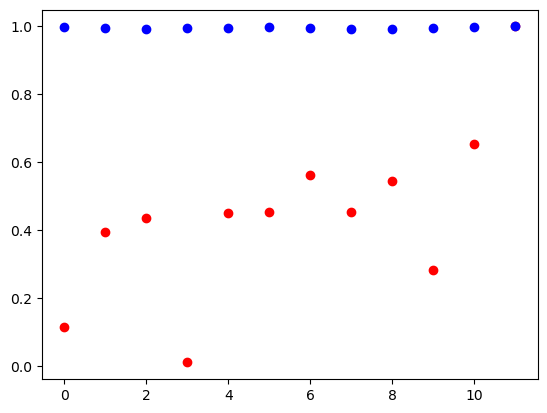

In [70]:
# Overlap between top eigenvector of close angle
# Should see V or trend over angles if FIXED = 0 if iangle then should see nothing?

raw_evals_store = np.zeros((12,50))
for iangle in range(12):
    FIXED = 0
    covariance_matrix_data1 = np.cov(Y_RING[:,FIXED,:], rowvar=False)  # shape (N, N)
    covariance_matrix_data2= np.cov(Y_RING[:,(iangle+1)%12,:], rowvar=False)  # shape (N, N)

    covariance_matrix_model1 = sigma_ring[(iangle+1)%12,:,:]
    covariance_matrix_model2 = sigma_ring[FIXED,:,:]

    _,evec_data1 = np.linalg.eigh(covariance_matrix_data1)
    _,evec_data2 = np.linalg.eigh(covariance_matrix_data2)
    _,evec_model1 = np.linalg.eigh(covariance_matrix_model1)
    _,evec_model2 = np.linalg.eigh(covariance_matrix_model2)

    overlap_data = np.dot(evec_data1[:,-1], evec_data2[:,-1])**2
    overlap_model = np.dot(evec_model1[:,-1], evec_model2[:,-1])**2

    plt.scatter(iangle, overlap_data,color  ='red')
    plt.scatter(iangle, overlap_model, color='blue')

# SNR Analysis

In [58]:
array_conditions = [12,36]
inference_seed=1
n_draws = 50

eigs_array = np.full((len(array_conditions),5, 12,N), np.nan)  #angular resolution x sfs x angles x eigvals
overlaps_array = np.full((len(array_conditions),5, 12,N), np.nan)  # angular resolution x sfs x angles x overlaps

for sfixd, sf in enumerate(sfs):
    og_indices = jnp.where(x_tr[:,1] == sf)[0]
    for idx, condition_number in enumerate(array_conditions):
        angles = jnp.linspace(0, 12-1, condition_number)
        X_TEST_CONDITIONS = jnp.stack(jnp.meshgrid(angles, sfs, indexing="ij"), axis=-1).reshape(-1, 2)
        indices = jnp.where(X_TEST_CONDITIONS[:,1] == sf)[0]
        with numpyro.handlers.seed(rng_seed=inference_seed):
            mu_d, _, _ = posterior.sample(X_TEST_CONDITIONS)  # (C,N), (C,N,N)
        mu_test_hat = mu_d  
        mu_ring = mu_test_hat[indices,:]
        sigma_ring = np.copy(sigma_hat)[og_indices,:,:]
        print(np.isnan(sigma_ring).any())
        print(np.isnan(mu_d).any())
        # overlaps_array = np.full((12, modes), np.nan)
        # eigs_array = np.full((12, modes), np.nan)
        for og_conds in range(12):
            eigvals, eigvecs = np.linalg.eigh(sigma_ring[og_conds,:,:])
            eigval_order = np.argsort(eigvals)[::-1]
            eigvals = eigvals[eigval_order] 
            eigvecs = eigvecs[:,eigval_order] 
            
            eigs_array[idx,sfixd,og_conds,:] = eigvals
            
            # find Delta Mu for each og_cond
            number_angles,number_evals = mu_test_hat.shape
            equivalent_cond = int((og_conds * condition_number) // 12)
            d_mu = mu_ring[og_conds,:] - mu_ring[(equivalent_cond+1)%number_angles,:]
            
            for evallss in range(N): # could also be the last modes
                overlap = np.power((np.dot(d_mu, eigvecs[:,evallss])),2)#/np.power(np.linalg.norm(d_mu)*np.linalg.norm(eigvecs[:,evallss]),2)
                overlaps_array[idx,sfixd,og_conds,evallss] = overlap 

False
False
False
True
False
False
False
True
False
False
False
True
False
False
False
True
False
False
False
True


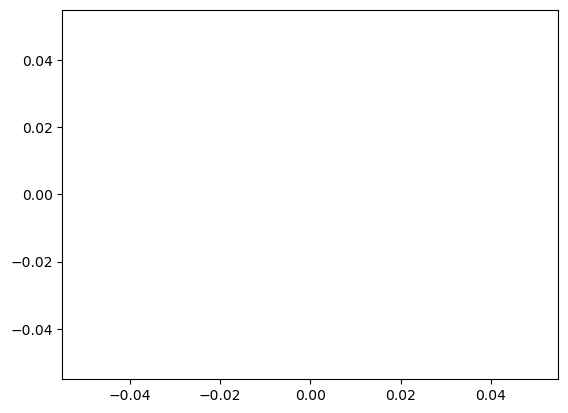

In [55]:
# plt.plot(np.mean(eigs_array[0,:, :, :], axis=(0,1)), np.mean(overlaps_array[0,:, :, :], axis=(0,1)))
plt.plot(np.mean(eigs_array[1,:, :, :], axis=(0,1)), np.mean(overlaps_array[1,:, :, :], axis=(0,1)))

In [ ]:
import numpy as np

# Random orthonormal a,b in R^N
N = 50
rng = np.random.default_rng(0)
a = rng.normal(size=N); a /= np.linalg.norm(a)
b = rng.normal(size=N); b -= a*(a@b); b /= np.linalg.norm(b)

def u(theta):
    return a*np.cos(theta) + b*np.sin(theta)

theta = 0.3  # arbitrary reference
u0 = u(theta)

deltas = np.array([1e-3, 1e-2, 0.05, 0.1, 0.3, np.pi/6, np.pi/4, np.pi/2, np.pi*0.8])
print("Delta(rad)   c(Δ)        alpha=c-1     cos(angle(u, chord))")
for d in deltas:
    u1 = u(theta + d)
    chord = u1 - u0
    c = (u0 @ u1) / (u0 @ u0)
    alpha = c - 1.0
    cosang = (u0 @ chord) / (np.linalg.norm(u0) * np.linalg.norm(chord))
    print(f"{d:8.4f}  {c:8.4f}    {alpha:10.4f}       {cosang:10.4f}")


Delta(rad)   c(Δ)        alpha=c-1     cos(angle(u, chord))
  0.0010    1.0000       -0.0000          -0.0005
  0.0100    1.0000       -0.0000          -0.0050
  0.0500    0.9988       -0.0012          -0.0250
  0.1000    0.9950       -0.0050          -0.0500
  0.3000    0.9553       -0.0447          -0.1494
  0.5236    0.8660       -0.1340          -0.2588
  0.7854    0.7071       -0.2929          -0.3827
  1.5708    0.0000       -1.0000          -0.7071
  2.5133   -0.8090       -1.8090          -0.9511


: 